https://towardsdatascience.com/audio-deep-learning-made-simple-part-3-data-preparation-and-augmentation-24c6e1f6b52/

In [1]:
import librosa
import torchaudio
import scipy
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
import requests

# URLs of sample wav files commonly used in deep learning projects
sample_urls = [
    "https://github.com/karoldvl/ESC-50/raw/master/audio/1-100032-A-0.wav",
    "https://github.com/karoldvl/ESC-50/raw/master/audio/1-100038-A-14.wav"
]

# Download and save the files locally
for idx, url in enumerate(sample_urls):
    response = requests.get(url)
    with open(f"sample_{idx+1}.wav", "wb") as f:
        f.write(response.content)

In [3]:
audio_files = [f"sample_{i+1}.wav" for i in range(len(sample_urls))]
samples, sample_rate = librosa.load(audio_files[1], sr=None)

print(samples.shape, sample_rate, samples.max(), samples.min())
print (samples[22400:22420])

(220500,) 44100 0.54556274 -0.48049927
[-0.32336426 -0.26290894 -0.11248779  0.08029175  0.24725342  0.32229614
  0.27200317  0.13772583  0.0123291  -0.05535889 -0.09664917 -0.13632202
 -0.17440796 -0.23342896 -0.284729   -0.22680664 -0.02880859  0.20639038
  0.34524536  0.33496094]


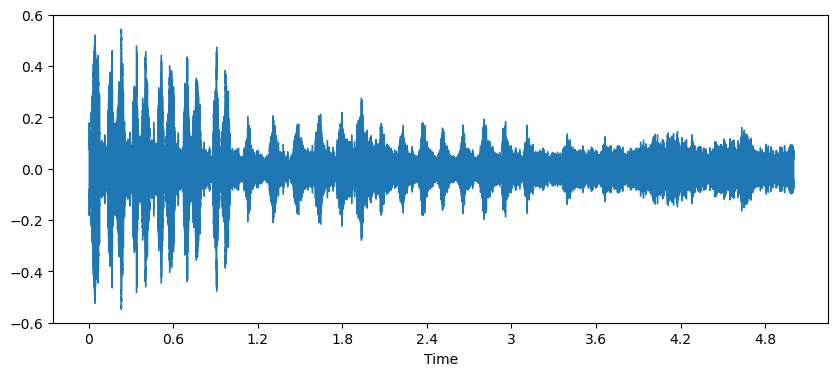

In [4]:
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.waveshow(samples, sr=sample_rate)

In [5]:
from IPython.display import Audio
Audio(audio_files[1], rate=sample_rate)

/tmp/ipykernel_107732/2304845838.py:2: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(sgram)


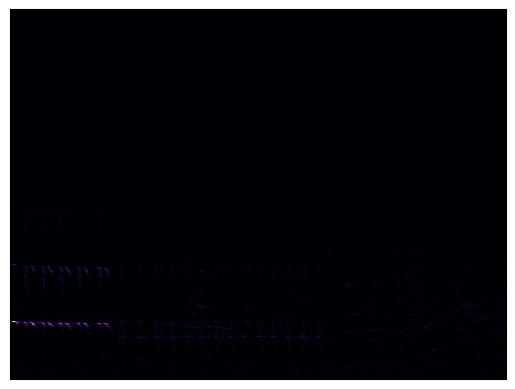

In [6]:
sgram = librosa.stft(samples)
librosa.display.specshow(sgram)

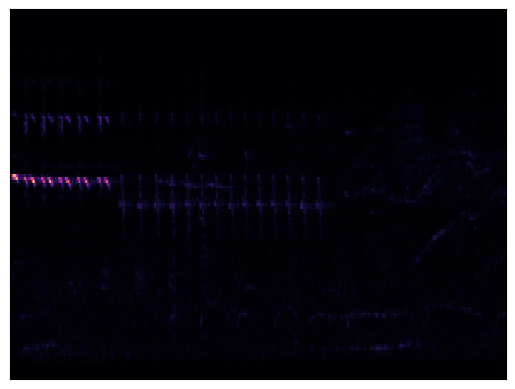

In [7]:
# use the mel-scale instead of raw frequency
sgram_mag, _ = librosa.magphase(sgram)
mel_scale_sgram = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
librosa.display.specshow(mel_scale_sgram)

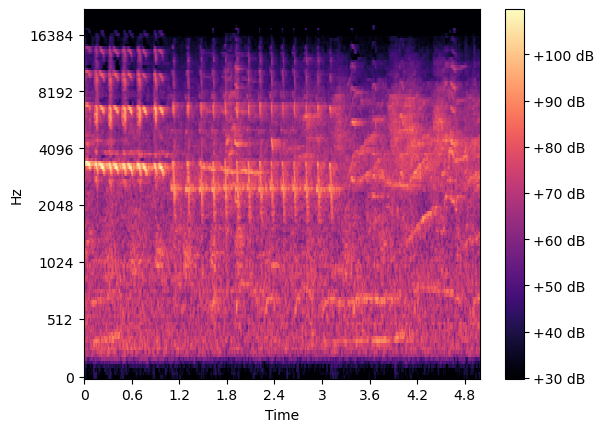

In [8]:
# use the decibel scale to get the final Mel Spectrogram
mel_sgram = librosa.amplitude_to_db(mel_scale_sgram, ref=np.min)
librosa.display.specshow(mel_sgram, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

(809508,) 44100
MFCC is of type <class 'numpy.ndarray'> with shape (16, 1582)


/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


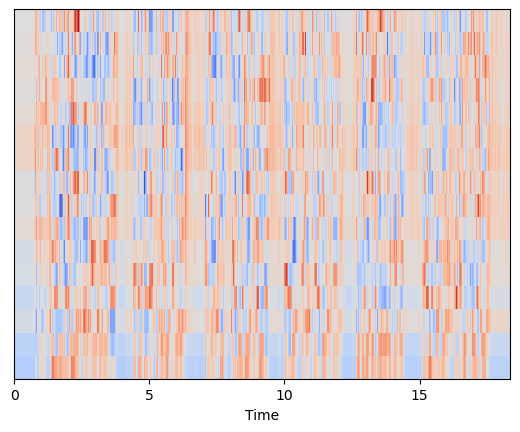

In [ ]:

import sklearn

# Load the speech audio using librosa
speech_samples, speech_sample_rate = librosa.load("./speech.wav", sr=None)
print(speech_samples.shape, speech_sample_rate)

mfcc = librosa.feature.mfcc(y=speech_samples, sr=speech_sample_rate, n_mfcc=13, n_fft=2048, hop_length=512)

# Center MFCC coefficient dimensions to the mean and unit variance
mfcc = sklearn.preprocessing.scale(mfcc, axis=1)
librosa.display.specshow(mfcc, sr=speech_sample_rate, x_axis='time')

print (f'MFCC is of type {type(mfcc)} with shape {mfcc.shape}')